# Phase 2: MAPPO robustness, transfer, and reports
Each experiment section can run after initialization in a fresh runtime. A fresh, post-repair Phase-1 baseline run and nominal IPPO run are mandatory: the gate below stops execution unless every safeguard passes. Never interpret Pymunk transfer as physical deployment.

## 1. Compact initialization

In [2]:
from pathlib import Path
import json, os, sys
REPO_URL = "https://github.com/djdhillxn/football"
REPO_DIR = Path("/content/robot-soccer-transfer")
DRIVE_MOUNT = Path("/content/drive")
DRIVE_PROJECT = DRIVE_MOUNT / "MyDrive" / "RobotSoccerTransfer"
!python --version
!nvidia-smi || true
from google.colab import drive
drive.mount(str(DRIVE_MOUNT))
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)
os.environ["ROBOSOCCER_DRIVE_PROJECT"] = str(DRIVE_PROJECT)
if REPO_DIR.exists():
    dirty = !git -C {REPO_DIR} status --porcelain
    if dirty:
        raise RuntimeError("Repository has local changes; refusing to overwrite them.")
    !git -C {REPO_DIR} fetch origin --quiet
    !git -C {REPO_DIR} pull --ff-only
else:
    if REPO_URL.startswith("REPLACE_"):
        raise RuntimeError("Set REPO_URL before cloning.")
    !git clone {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git rev-parse HEAD
# Preserve Colab's CUDA-enabled Torch, NumPy, and pandas builds.
!python -m pip install -q gymnasium==1.2.1 pettingzoo==1.26.1 pymunk==7.3.0 PyYAML==6.0.3 tensorboard==2.20.0 imageio==2.37.2 imageio-ffmpeg==0.6.0 pytest==8.4.2 ruff==0.14.5
if int(get_ipython().user_ns.get("_exit_code", 0)) != 0:
    raise RuntimeError("dependency installation failed")
!python -m pip install -e . --no-deps -q
if int(get_ipython().user_ns.get("_exit_code", 0)) != 0:
    raise RuntimeError("editable package installation failed")
sys.path.insert(0, str(REPO_DIR))
import torch, robosoccer
print("torch", torch.__version__, "cuda", torch.cuda.is_available(), "project", robosoccer.__version__)

Mounted at /content/drive
Cloning into '/content/robot-soccer-transfer'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 95 (delta 30), reused 89 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 136.16 KiB | 352.00 KiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/robot-soccer-transfer
45e80751d4d48ce26f3c74c38e1dc018c713e460
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 951.1/951.1 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 153.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to bui

In [3]:
def require_shell_success(label):
    status = int(get_ipython().user_ns.get("_exit_code", 0))
    if status != 0:
        raise RuntimeError(f"{label} failed with shell status {status}")

def latest_run(name):
    pointer = REPO_DIR / "runs" / f"latest_{name}.txt"
    if not pointer.is_file():
        raise FileNotFoundError(pointer)
    run_dir = Path(pointer.read_text().strip())
    return run_dir if run_dir.is_absolute() else (REPO_DIR / run_dir).resolve()

def display_json(path):
    data = json.loads(Path(path).read_text())
    print(json.dumps(data, indent=2)[:5000])
    return data

from robosoccer.config import load_config
from robosoccer.evaluation import phase1_readiness_audit
from robosoccer.artifacts import (
    sync_artifacts_from_drive,
    sync_auxiliary_artifacts_to_drive,
    sync_run_to_drive,
    sync_workspace_to_drive,
)

def local_run_names():
    runs_root = REPO_DIR / "runs"
    return {path.name for path in runs_root.iterdir() if path.is_dir()} if runs_root.is_dir() else set()

def sync_training_result(previous_runs, label):
    status = int(get_ipython().user_ns.get("_exit_code", 0))
    new_runs = sorted(local_run_names() - set(previous_runs))
    finished = []
    for name in new_runs:
        run_dir = REPO_DIR / "runs" / name
        metadata_path = run_dir / "run_metadata.json"
        if metadata_path.is_file():
            metadata = json.loads(metadata_path.read_text())
            if metadata.get("status") in {"complete", "failed"}:
                finished.append(run_dir)
    if not finished:
        if status != 0:
            raise RuntimeError(f"{label} failed with shell status {status}; no finished run was created.")
        raise RuntimeError(f"{label} completed without creating a finished run directory.")
    run_dir = finished[-1]
    print(json.dumps(sync_run_to_drive(run_dir, DRIVE_PROJECT), indent=2))
    if status != 0:
        raise RuntimeError(f"{label} failed with shell status {status}; diagnostics were saved to Drive.")
    return run_dir

def sync_run_after_command(run_dir, label):
    status = int(get_ipython().user_ns.get("_exit_code", 0))
    print(json.dumps(sync_run_to_drive(run_dir, DRIVE_PROJECT), indent=2))
    if status != 0:
        raise RuntimeError(f"{label} failed with shell status {status}; diagnostics were saved to Drive.")
    return Path(run_dir)

def sync_auxiliary_after_command(label, include_reports=True):
    status = int(get_ipython().user_ns.get("_exit_code", 0))
    result = sync_auxiliary_artifacts_to_drive(DRIVE_PROJECT, REPO_DIR, include_reports)
    print(json.dumps(result, indent=2))
    if status != 0:
        raise RuntimeError(f"{label} failed with shell status {status}; partial artifacts were saved.")
    return result

def require_phase1_go():
    baseline_run = latest_run("base")
    ippo_run = latest_run("ippo_nominal")
    baseline_summary = json.loads((baseline_run / "eval" / "baseline_summary.json").read_text())
    abstract_summary = json.loads((ippo_run / "eval" / "abstract_standard" / "summary.json").read_text())
    transfer_summary = json.loads((ippo_run / "eval" / "pymunk_transfer" / "summary.json").read_text())
    audit = phase1_readiness_audit(
        load_config(REPO_DIR / "configs" / "base.yaml"),
        baseline_summary,
        abstract_summary,
        transfer_summary,
    )
    print(json.dumps(audit, indent=2))
    if not audit["phase2_ready"]:
        raise RuntimeError("PHASE 2 NO-GO: rerun or repair Phase 1 before training MAPPO.")
    print("PHASE 2 GO: all Phase-1 safeguards passed.")
    return audit

In [4]:
# Restore every finished run and generated report artifact into this fresh runtime.
drive_sync = sync_artifacts_from_drive(
    DRIVE_PROJECT, REPO_DIR, include_training_artifacts=True
)
print(json.dumps(drive_sync, indent=2))

{
  "drive_project": "/content/drive/MyDrive/RobotSoccerTransfer",
  "repository_root": "/content/robot-soccer-transfer",
  "copied_run_files": 141,
  "copied_report_files": 2,
  "changed_runs": [
    "20260721_055932_smoke_test_mappo_seed0",
    "20260721_055953_baselines_heuristic_seed0",
    "20260721_060143_ippo_nominal_ippo_seed0",
    "20260721_095003_smoke_test_mappo_seed0",
    "20260721_095025_baselines_heuristic_seed0",
    "20260721_095134_ippo_nominal_ippo_seed0"
  ],
  "skipped_running": [],
  "skipped_invalid": [],
  "skipped_unchanged": [],
  "training_artifacts_included": true,
  "latest_pointers": {
    "base": "/content/robot-soccer-transfer/runs/20260721_095025_baselines_heuristic_seed0",
    "ippo_nominal": "/content/robot-soccer-transfer/runs/20260721_095134_ippo_nominal_ippo_seed0",
    "smoke_test": "/content/robot-soccer-transfer/runs/20260721_095003_smoke_test_mappo_seed0"
  }
}


## 2. Restore the required Phase-1 artifacts and enforce the gate

In [5]:
# The preceding full pull restored Phase-1 artifacts and rebuilt local pointers.
phase1_audit = require_phase1_go()

{
  "baseline_ready": true,
  "phase2_ready": true,
  "checks": {
    "bounded_fraction_metrics": {
      "passed": true,
      "observed": true,
      "criterion": "every reported fraction is in [0, 1]"
    },
    "baseline_evaluation_complete": {
      "passed": true,
      "observed": {
        "random__abstract": 100,
        "random__pymunk": 100,
        "double_chase__abstract": 100,
        "double_chase__pymunk": 100,
        "role_based__abstract": 100,
        "role_based__pymunk": 100
      },
      "criterion": "each scripted method/simulator cell has at least 100 episodes"
    },
    "pymunk_random_not_saturated": {
      "passed": true,
      "observed": 0.49,
      "criterion": "random Pymunk success <= 0.5"
    },
    "pymunk_policy_sensitive": {
      "passed": true,
      "observed": 0.19000000000000006,
      "criterion": "Pymunk scripted-method success spread >= 0.15"
    },
    "role_success_exceeds_random": {
      "passed": true,
      "observed": {
        "abs

## 3. Train nominal MAPPO
This section is reachable only after the Phase-1 audit reports `phase2_ready: true`.

In [6]:
previous_runs = local_run_names()
!python -m scripts.train --config configs/mappo_nominal.yaml
nominal_run = sync_training_result(previous_runs, "nominal MAPPO training")

2026-07-22 00:24:43.524726: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 00:24:43.597092: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-07-22 00:24:45,405:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

  ParserElement.enablePackrat()

INFO: Training MAPPO with 32 environments for 2,000,000 steps.
MAPPO:   0% 0/245 [00:00<?, ?it/

## 4. Train uniformly randomized MAPPO

In [7]:
previous_runs = local_run_names()
!python -m scripts.train --config configs/mappo_uniform_dr.yaml
uniform_run = sync_training_result(previous_runs, "uniform-randomization MAPPO training")

2026-07-22 02:04:58.572152: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 02:04:58.644738: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-07-22 02:05:00,407:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

  ParserElement.enablePackrat()

INFO: Training MAPPO with 32 environments for 2,000,000 steps.
MAPPO:   0% 0/245 [00:00<?, ?it/

## 5. Train failure-directed MAPPO

In [8]:
previous_runs = local_run_names()
!python -m scripts.train --config configs/mappo_failure_dr.yaml
failure_run = sync_training_result(previous_runs, "failure-directed MAPPO training")

2026-07-22 03:32:17.498094: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 03:32:17.568733: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-07-22 03:32:19,347:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

  ParserElement.enablePackrat()

INFO: Training MAPPO with 32 environments for 2,000,000 steps.
MAPPO:   0% 0/245 [00:00<?, ?it/

## 6. Optional focused ablations

In [ ]:
# Run only after the primary methods and only if the experiment budget allows.
previous_runs = local_run_names()
!python -m scripts.train --config configs/mappo_failure_dr.yaml --run-name mappo_failure_no_action_delay 'randomization.disabled_families=[action_delay]'
delay_ablation_run = sync_training_result(previous_runs, "action-delay ablation")
previous_runs = local_run_names()
!python -m scripts.train --config configs/mappo_failure_dr.yaml --run-name mappo_failure_no_communication 'randomization.disabled_families=[communication]'
communication_ablation_run = sync_training_result(previous_runs, "communication ablation")
# Optional: replace the family below with observation_noise.
# previous_runs = local_run_names()
#!python -m scripts.train --config configs/mappo_failure_dr.yaml --run-name mappo_failure_no_observation_noise 'randomization.disabled_families=[observation_noise]'
# observation_ablation_run = sync_training_result(previous_runs, "observation-noise ablation")

## 7. Evaluate learned policies in the abstract simulator

In [9]:
for experiment in ["mappo_nominal", "mappo_uniform_dr", "mappo_failure_dr"]:
    run_dir = latest_run(experiment)
    !python -m scripts.evaluate --run-dir {run_dir} --checkpoint best --simulator abstract --suite standard
    sync_run_after_command(run_dir, f"{experiment} abstract evaluation")

Standard: 100% 300/300 [00:17<00:00, 17.20it/s]
INFO: Evaluation complete | abstract standard | episodes 300 | success 0.413
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_002437_mappo_nominal_mappo_seed0",
  "copied_files": 4,
  "status": "complete"
}
Standard: 100% 300/300 [00:24<00:00, 12.40it/s]
INFO: Evaluation complete | abstract standard | episodes 300 | success 0.337
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_020456_mappo_uniform_dr_mappo_seed0",
  "copied_files": 4,
  "status": "complete"
}
Standard: 100% 300/300 [00:26<00:00, 11.21it/s]
INFO: Evaluation complete | abstract standard | episodes 300 | success 0.337
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0",
  "copied_files": 4,
  "status": "complete"
}


## 8. Evaluate the same frozen actors in Pymunk

In [10]:
for experiment in ["mappo_nominal", "mappo_uniform_dr", "mappo_failure_dr"]:
    run_dir = latest_run(experiment)
    !python -m scripts.evaluate --run-dir {run_dir} --checkpoint best --simulator pymunk --suite transfer
    sync_run_after_command(run_dir, f"{experiment} Pymunk transfer evaluation")

Transfer: 100% 100/100 [00:16<00:00,  6.08it/s]
INFO: Evaluation complete | pymunk transfer | episodes 100 | success 0.440
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_002437_mappo_nominal_mappo_seed0",
  "copied_files": 5,
  "status": "complete"
}
Transfer: 100% 100/100 [00:21<00:00,  4.74it/s]
INFO: Evaluation complete | pymunk transfer | episodes 100 | success 0.380
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_020456_mappo_uniform_dr_mappo_seed0",
  "copied_files": 5,
  "status": "complete"
}
Transfer: 100% 100/100 [00:12<00:00,  8.04it/s]
INFO: Evaluation complete | pymunk transfer | episodes 100 | success 0.640
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0",
  "copied_files": 5,
  "status": "complete"
}


## 9. Run profile evaluations

In [11]:
for experiment in ["mappo_nominal", "mappo_uniform_dr", "mappo_failure_dr"]:
    run_dir = latest_run(experiment)
    !python -m scripts.evaluate --run-dir {run_dir} --checkpoint best --simulator pymunk --suite profiles
    sync_run_after_command(run_dir, f"{experiment} profile evaluation")

Profiles: 100% 900/900 [02:57<00:00,  5.08it/s]
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

INFO: generated new fontManager
  ParserElement.enablePackrat()

INFO: Evaluation complete | pymunk profiles | episodes 900 | success 0.417
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_002437_mappo_nominal_mappo_seed0",
  "copied_files": 5,
  "status": "complete"
}
Profiles: 100% 900/900 [03:39<00:00,  4.11it/s]
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

  ParserElement.enablePackrat()

INFO: Evaluation complete | pymunk profiles | episodes 900 | success 0.416
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_020456_mappo_uniform_dr_mappo_seed0",
  "copied_files": 5,
  "status": "complete"
}
Profiles: 100% 900/900 [03:13<00:00,  4.66i

## 10. Run robustness grids

In [12]:
for experiment in ["mappo_nominal", "mappo_uniform_dr", "mappo_failure_dr"]:
    run_dir = latest_run(experiment)
    !python -m scripts.evaluate --run-dir {run_dir} --checkpoint best --simulator pymunk --suite robustness
    sync_run_after_command(run_dir, f"{experiment} robustness grid")

  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

  ParserElement.enablePackrat()

Robustness grid: 100% 500/500 [01:31<00:00,  5.44it/s]
INFO: Evaluation complete | pymunk robustness | episodes 500 | success 0.494
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_002437_mappo_nominal_mappo_seed0",
  "copied_files": 11,
  "status": "complete"
}
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

  ParserElement.enablePackrat()

Robustness grid: 100% 500/500 [02:29<00:00,  3.34it/s]
INFO: Evaluation complete | pymunk robustness | episodes 500 | success 0.346
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_020456_mappo_uniform_dr_mappo_seed0",
  "copied_files": 11,
  "status": "complete"
}
  prop = Group((name + Suppress("=") + comma_separated(

## 11. Record nominal and transfer videos

In [13]:
failure_run = latest_run("mappo_failure_dr")
!python -m scripts.record_video --run-dir {failure_run} --checkpoint best --simulator abstract --episodes 3
sync_run_after_command(failure_run, "failure-directed abstract videos")
!python -m scripts.record_video --run-dir {failure_run} --checkpoint best --simulator pymunk --episodes 3
sync_run_after_command(failure_run, "failure-directed transfer videos")

INFO: Recorded /content/robot-soccer-transfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0/videos/mappo_failure_dr_abstract_seed50000_success.mp4
INFO: Recorded /content/robot-soccer-transfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0/videos/mappo_failure_dr_abstract_seed50002_out_of_bounds.mp4
INFO: Recorded /content/robot-soccer-transfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0/videos/mappo_failure_dr_abstract_seed50001_success.mp4
{
  "destination": "/content/drive/MyDrive/RobotSoccerTransfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0",
  "copied_files": 5,
  "status": "complete"
}
INFO: Recorded /content/robot-soccer-transfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0/videos/mappo_failure_dr_pymunk_seed50000_success.mp4
INFO: Recorded /content/robot-soccer-transfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0/videos/mappo_failure_dr_pymunk_seed50004_out_of_bounds.mp4
INFO: Recorded /content/robot-soccer-transfer/runs/20260722_033215_mappo_fai

PosixPath('/content/robot-soccer-transfer/runs/20260722_033215_mappo_failure_dr_mappo_seed0')

## 12. Compare all completed runs

In [14]:
!python -m scripts.compare_runs --phase final --export-report
sync_auxiliary_after_command("final run comparison")

  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

  parse = parser.parseString(pattern)

  parser.resetCache()

  ParserElement.enablePackrat()

INFO: Comparison artifacts written to runs/comparisons/20260722_052400_final
{
  "comparison_files": 9,
  "manual_video_files": 0,
  "report_files": 7,
  "sync_log_files": 0
}


{'comparison_files': 9,
 'manual_video_files': 0,
 'report_files': 7,
 'sync_log_files': 0}

## 13. Display the main CSV and selected figures

,run_dir,method,simulator,collision_rate,cvar_10_return,episode_count,invalid_action_rate,mean_action_switches,mean_profile_success_rate,mean_return,...,success_rate,success_rate_95_ci,worst_decile_return,by_defender_mode,checkpoint,normalized_area_under_robustness_curve,suite,transfer_gaps,mean_defender_mode_success_rate,minimum_defender_mode_success_rate
0,/content/robot-soccer-transfer/runs/20260721_0...,double_chase,abstract,1.000000,-11.134416,100,0.351319,13.810000,0.300000,-1.955609,...,0.300000,"[0.21, 0.39]",-11.134416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/content/robot-soccer-transfer/runs/20260721_0...,double_chase,pymunk,0.990000,-10.029468,100,0.080839,8.270000,0.730000,5.128679,...,0.730000,"[0.64, 0.81]",-10.029468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/content/robot-soccer-transfer/runs/20260721_0...,random,abstract,0.940000,-9.481882,100,0.543278,81.900000,0.110000,-3.876047,...,0.110000,"[0.05, 0.18]",-9.481882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,/content/robot-soccer-transfer/runs/20260721_0...,random,pymunk,0.610000,-26.771947,100,0.555640,95.760000,0.760000,-0.266351,...,0.760000,"[0.68, 0.84]",-26.771947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,/content/robot-soccer-transfer/runs/20260721_0...,role_based,abstract,0.100000,-3.719166,100,0.060349,7.020000,0.060000,-1.667477,...,0.060000,"[0.02, 0.11]",-3.719166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,/content/robot-soccer-transfer/runs/20260721_0...,role_based,pymunk,0.460000,-11.880451,100,0.073829,12.730000,0.740000,5.651831,...,0.740000,"[0.66, 0.82]",-11.880451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,/content/robot-soccer-transfer/runs/20260721_0...,ippo_nominal,pymunk,0.300000,-11.751049,100,0.557757,35.950000,0.730000,4.667546,...,0.730000,"[0.65, 0.81]",-11.751049,"{'intercept': {'collision_rate': 0.3, 'cvar_10...",/content/robot-soccer-transfer/runs/20260721_0...,NaN,transfer,{'transfer_gap_mean_return': 2.801019257603014...,NaN,NaN
7,/content/robot-soccer-transfer/runs/20260721_0...,ippo_nominal,abstract,0.460000,-5.234161,300,0.291211,29.746667,0.453333,2.336996,...,0.453333,"[0.3999166666666667, 0.51]",-5.234161,"{'chase_ball': {'collision_rate': 0.38, 'cvar_...",/content/robot-soccer-transfer/runs/20260721_0...,NaN,standard,NaN,NaN,NaN
8,/content/robot-soccer-transfer/runs/20260721_0...,double_chase,abstract,1.000000,-9.760612,100,0.170246,12.320000,NaN,-3.623862,...,0.150000,"[0.08, 0.22024999999999978]",-9.760612,NaN,NaN,NaN,NaN,NaN,0.150000,0.15
9,/content/robot-soccer-transfer/runs/20260721_0...,double_chase,pymunk,0.950000,-4.640450,100,0.043063,6.630000,NaN,5.526350,...,0.680000,"[0.58, 0.77]",-4.640450,NaN,NaN,NaN,NaN,NaN,0.680000,0.68


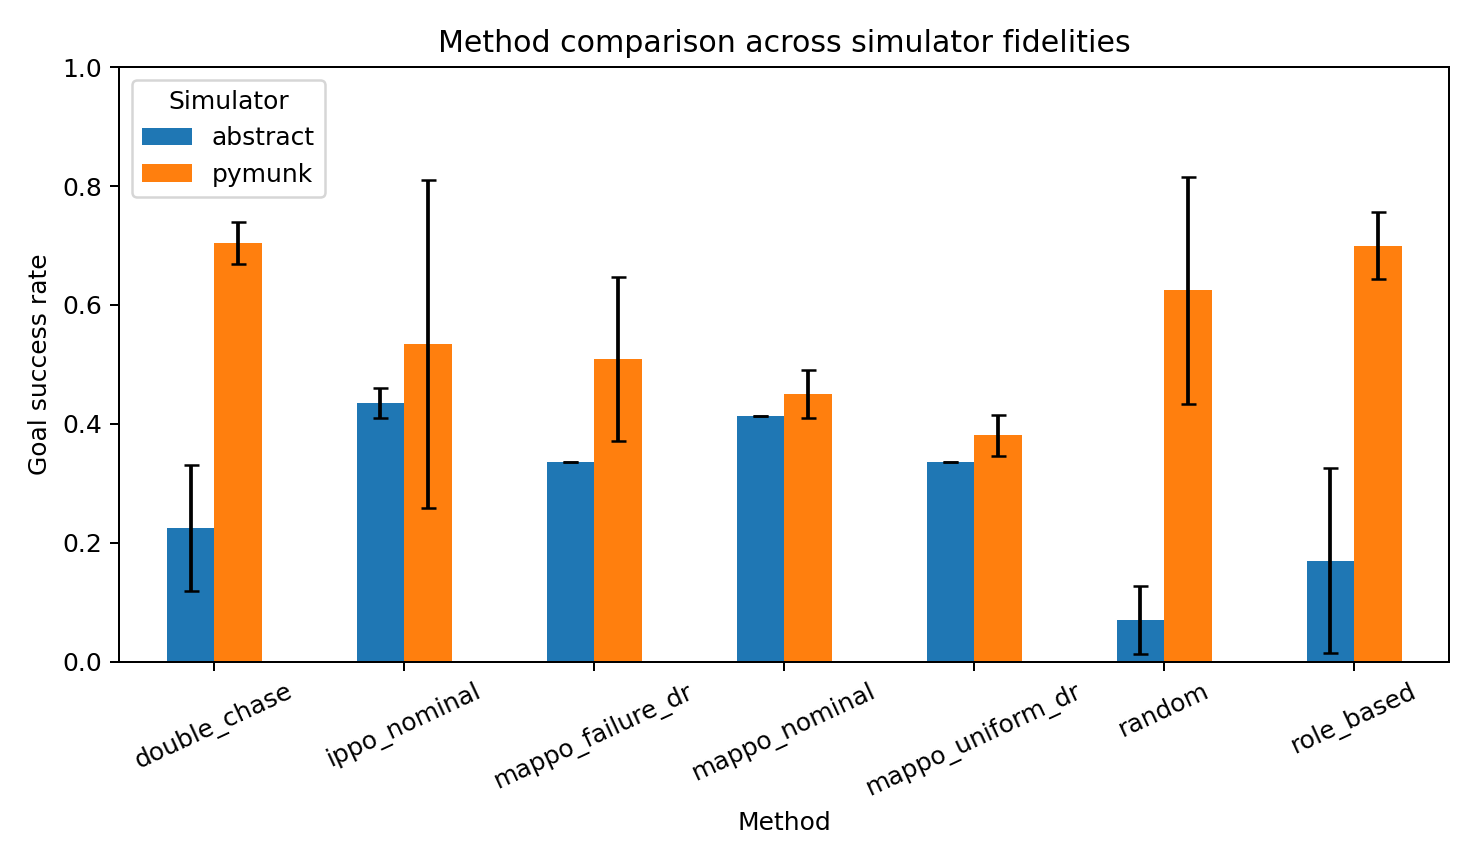

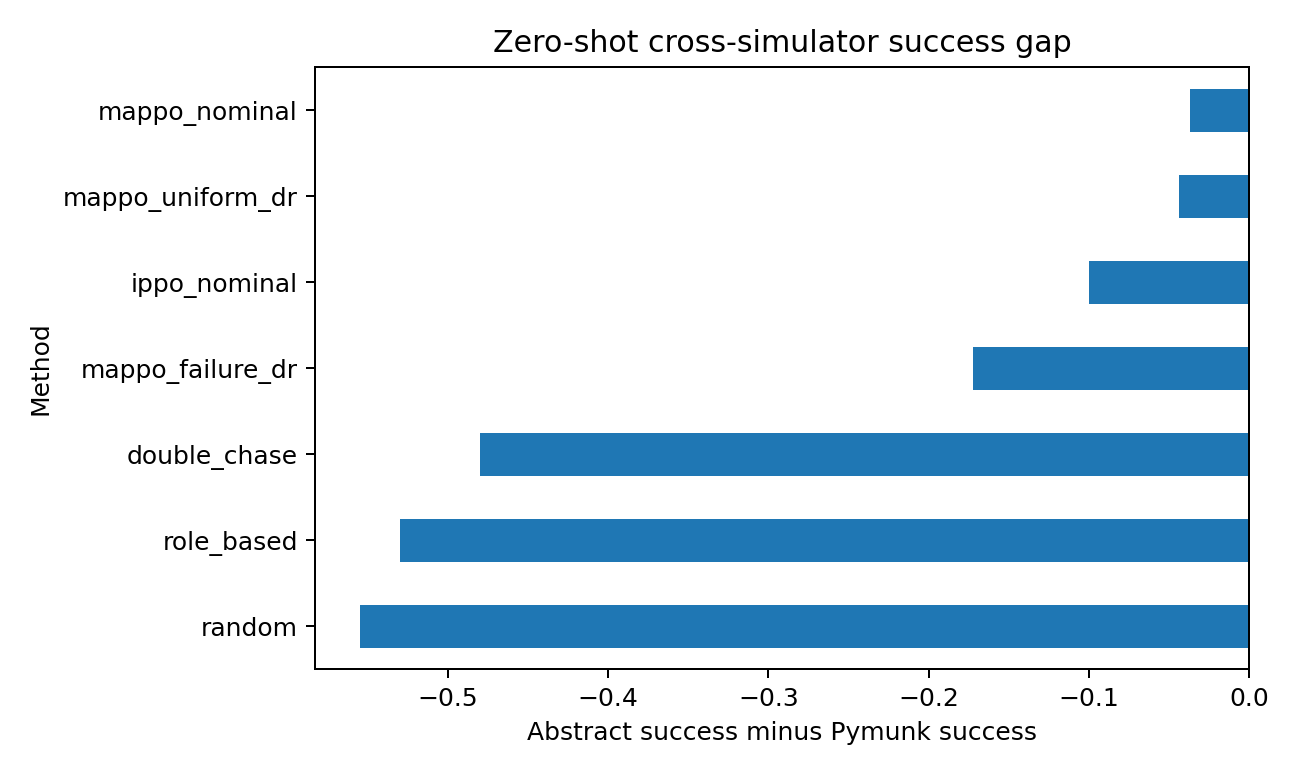

In [15]:
import pandas as pd
from IPython.display import display, Image as DisplayImage
comparison_dir = sorted((REPO_DIR / "runs" / "comparisons").glob("*_final"))[-1]
display(pd.read_csv(comparison_dir / "main_comparison.csv"))
for figure in [comparison_dir / "method_success_comparison.png", comparison_dir / "transfer_gap.png"]:
    if figure.is_file():
        display(DisplayImage(filename=str(figure)))

## 14. Build the main paper-style report

In [16]:
!latexmk -pdf -interaction=nonstopmode -halt-on-error -outdir=reports reports/main.tex
sync_auxiliary_after_command("main report build")

/bin/bash: line 1: latexmk: command not found
{
  "comparison_files": 0,
  "manual_video_files": 0,
  "report_files": 0,
  "sync_log_files": 0
}


RuntimeError: main report build failed with shell status 127; partial artifacts were saved.

## 15. Build the detailed surrogate report

In [17]:
!latexmk -pdf -interaction=nonstopmode -halt-on-error -outdir=reports reports/surrogate_notes.tex
sync_auxiliary_after_command("surrogate report build")

/bin/bash: line 1: latexmk: command not found
{
  "comparison_files": 0,
  "manual_video_files": 0,
  "report_files": 0,
  "sync_log_files": 0
}


RuntimeError: surrogate report build failed with shell status 127; partial artifacts were saved.

## 16. Sync runs, reports, PDFs, plots, and videos to Drive

In [18]:
# Safety net only; every expensive section above already saves immediately.
print(json.dumps(sync_workspace_to_drive(DRIVE_PROJECT, REPO_DIR), indent=2))

{
  "synced_runs": [
    "20260721_055932_smoke_test_mappo_seed0",
    "20260721_055953_baselines_heuristic_seed0",
    "20260721_060143_ippo_nominal_ippo_seed0",
    "20260721_095003_smoke_test_mappo_seed0",
    "20260721_095025_baselines_heuristic_seed0",
    "20260721_095134_ippo_nominal_ippo_seed0",
    "20260722_002437_mappo_nominal_mappo_seed0",
    "20260722_020456_mappo_uniform_dr_mappo_seed0",
    "20260722_033215_mappo_failure_dr_mappo_seed0"
  ],
  "auxiliary": {
    "comparison_files": 0,
    "manual_video_files": 0,
    "report_files": 0,
    "sync_log_files": 0
  }
}


## 17. Finished
Confirm the Drive copies and compiled PDFs, record failed or excluded runs in `surrogate_notes.tex`, and disconnect the Colab runtime.